<h1> IMU Feature level Ablation Study </h1>

In [2]:
# ================= FEATURE GROUP ABLATION STUDY =================
# Paste this AFTER df_feat is built in your existing script.
# Runs RF only; reports Accuracy, Macro P/R/F1, Top-5 feature importance
# for each feature group under both 80/20 and LOSO evaluation.

from sklearn.metrics import precision_recall_fscore_support

# ── Define feature groups ──────────────────────────────────────────────────
FEATURE_GROUPS = {
    "Time-Domain": [
        "mean", "median", "std", "rms", "range", "skew", "kurt", "iqr", "mav", "zcr", "ll"
    ],
    "Derivative": [
        "vel_mean", "vel_std", "vel_max", "acc_mean", "acc_std", "acc_max"
    ],
    "Hjorth": [
        "hj_activity", "hj_mobility", "hj_complexity"
    ],
    "Frequency-Domain": [
        "dom_freq", "spec_entropy", "low_freq_power", "high_freq_power",
        "low_freq_ratio", "high_freq_ratio"
    ],
}
FEATURE_GROUPS["All Features"] = sum(FEATURE_GROUPS.values(), [])

RF_ABL = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# ── Helper: metrics + top-5 importance ────────────────────────────────────
def summarise(y_true, y_pred, feature_cols, importances):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    top5_idx = np.argsort(importances)[::-1][:5]
    top5 = [(feature_cols[i], round(importances[i], 4)) for i in top5_idx]
    return acc, p, r, f, top5

# ── 80/20 per-subject ablation ─────────────────────────────────────────────
def ablation_8020(df_feat, y_array, labels, task_name):
    print(f"\n{'='*60}")
    print(f"  ABLATION — 80/20  |  {task_name}")
    print(f"{'='*60}")

    rows = []
    for grp_name, cols in FEATURE_GROUPS.items():
        cols = [c for c in cols if c in df_feat.columns]  # safety check
        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for pid in df_feat["participant"].unique():
            sub = df_feat[df_feat["participant"] == pid]
            if len(sub) < 5:
                continue
            X_sub = sub[cols].reset_index(drop=True)
            y_sub = y_array[sub.index].reset_index(drop=True)

            split = int(0.8 * len(X_sub))
            X_tr, X_te = X_sub.iloc[:split], X_sub.iloc[split:]
            y_tr, y_te = y_sub.iloc[:split], y_sub.iloc[split:]

            if len(np.unique(y_tr)) < len(labels):
                continue

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            clf = RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=5,
                class_weight="balanced", random_state=42, n_jobs=-1,
            )
            clf.fit(X_tr_s, y_tr)
            all_true.append(y_te.values)
            all_pred.append(clf.predict(X_te_s))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise(
            np.concatenate(all_true),
            np.concatenate(all_pred),
            cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "80/20",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── LOSO ablation ──────────────────────────────────────────────────────────
def ablation_loso(df_feat, y_array, labels, task_name):
    print(f"\n{'='*60}")
    print(f"  ABLATION — LOSO   |  {task_name}")
    print(f"{'='*60}")

    logo = LeaveOneGroupOut()
    groups = df_feat["participant"].reset_index(drop=True)
    rows = []

    for grp_name, cols in FEATURE_GROUPS.items():
        cols = [c for c in cols if c in df_feat.columns]
        X = df_feat[cols].reset_index(drop=True)
        y = y_array.reset_index(drop=True)

        scaler = StandardScaler()
        X_s = scaler.fit_transform(X)

        all_true, all_pred = [], []
        all_imp = np.zeros(len(cols))
        n_folds = 0

        for tr_idx, te_idx in logo.split(X_s, y, groups):
            y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
            if len(np.unique(y_tr)) < len(labels):
                continue

            clf = RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=5,
                class_weight="balanced", random_state=42, n_jobs=-1,
            )
            clf.fit(X_s[tr_idx], y_tr)
            all_true.append(y_te.values)
            all_pred.append(clf.predict(X_s[te_idx]))
            all_imp += clf.feature_importances_
            n_folds += 1

        if not all_true:
            continue

        all_imp /= max(n_folds, 1)
        acc, p, r, f, top5 = summarise(
            np.concatenate(all_true),
            np.concatenate(all_pred),
            cols, all_imp
        )

        print(f"\n  Group : {grp_name}")
        print(f"  Acc={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
        print(f"  Top-5 RF importance: {top5}")
        rows.append({
            "Group": grp_name, "Eval": "LOSO",
            "Acc": round(acc,3), "Precision": round(p,3),
            "Recall": round(r,3), "F1": round(f,3),
            "Top5": top5,
        })
    return rows

# ── RUN both tasks ─────────────────────────────────────────────────────────
print("\n\n" + "#"*60)
print("  IMU FEATURE GROUP ABLATION STUDY")
print("#"*60)

# Binary
y_bin_abl = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 1})
labels_bin_abl = ["D1", "Slouch"]

rows_bin  = ablation_8020(df_feat, y_bin_abl,  labels_bin_abl,  "Binary  (D1 vs D2+D3)")
rows_bin += ablation_loso(df_feat, y_bin_abl,  labels_bin_abl,  "Binary  (D1 vs D2+D3)")

# Multiclass
y_mc_abl = df_feat["label"].map({"d1": 0, "d2": 1, "d3": 2})
labels_mc_abl = ["D1", "D2", "D3"]

rows_mc  = ablation_8020(df_feat, y_mc_abl, labels_mc_abl, "Multiclass (D1/D2/D3)")
rows_mc += ablation_loso(df_feat, y_mc_abl, labels_mc_abl, "Multiclass (D1/D2/D3)")

# ── Summary tables ─────────────────────────────────────────────────────────
df_bin_abl = pd.DataFrame(rows_bin)
df_mc_abl  = pd.DataFrame(rows_mc)

print("\n\n── Binary Ablation Summary ──")
print(df_bin_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))

print("\n── Multiclass Ablation Summary ──")
print(df_mc_abl[["Group","Eval","Acc","Precision","Recall","F1"]].to_string(index=False))

NameError: name 'RandomForestClassifier' is not defined

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/table17_horizontal_alerts_response_rate.pdf'

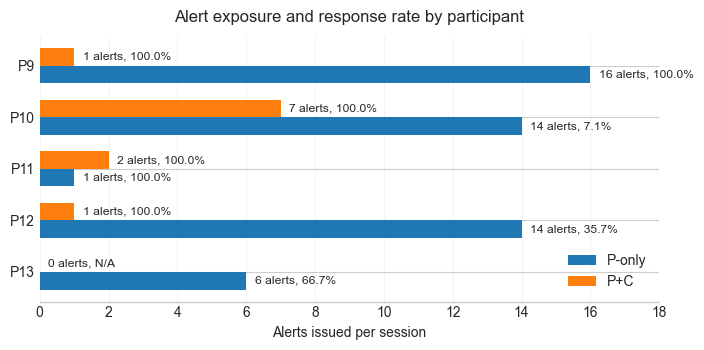

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

participants = ["P9", "P10", "P11", "P12", "P13"]
p_only_alerts = np.array([16, 14, 1, 14, 6])
pc_alerts = np.array([1, 7, 2, 1, 0])
p_only_rate = ["100.0%", "7.1%", "100.0%", "35.7%", "66.7%"]
pc_rate = ["100.0%", "100.0%", "100.0%", "100.0%", "N/A"]

y = np.arange(len(participants))
bar_h = 0.34

fig, ax = plt.subplots(figsize=(7.2, 3.6))

bars_ponly = ax.barh(y + bar_h/2, p_only_alerts, height=bar_h, label="P-only")
bars_pc = ax.barh(y - bar_h/2, pc_alerts, height=bar_h, label="P+C")

# Labels at the end of bars: count + response rate
for i, (bar, rate) in enumerate(zip(bars_ponly, p_only_rate)):
    width = bar.get_width()
    ax.text(width + 0.25, bar.get_y() + bar.get_height()/2, f"{int(width)} alerts, {rate}",
            va="center", fontsize=8.7)

for i, (bar, rate) in enumerate(zip(bars_pc, pc_rate)):
    width = bar.get_width()
    label_x = width + 0.25 if width > 0 else 0.25
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f"{int(width)} alerts, {rate}",
            va="center", fontsize=8.7)

ax.set_yticks(y)
ax.set_yticklabels(participants)
ax.invert_yaxis()
ax.set_xlabel("Alerts issued per session")
ax.set_title("Alert exposure and response rate by participant", pad=10)
ax.set_xlim(0, 18)
ax.set_xticks(np.arange(0, 19, 2))
ax.grid(True, axis="x", linewidth=0.4, alpha=0.45)
ax.legend(frameon=False, loc="lower right")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

out_dir = Path("/mnt/data")
pdf_path = out_dir / "table17_horizontal_alerts_response_rate.pdf"
png_path = out_dir / "table17_horizontal_alerts_response_rate.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")